In [182]:
# Cellule 1 — Imports

In [183]:
# # ── Manipulation données ──────────────────────────────────────
# import pandas as pd
# import numpy as np

# # ── Visualisation ─────────────────────────────────────────────
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# import seaborn as sns

# # ── Connexion SQL Server ──────────────────────────────────────
# import pyodbc
# print(pyodbc.drivers())

# # ── Utilitaires ───────────────────────────────────────────────
# import warnings
# import os
# from datetime import datetime

# from IPython.display import display

# warnings.filterwarnings('ignore')

# # ── Style global des graphes ──────────────────────────────────
# sns.set_theme(style="whitegrid", palette="muted")
# plt.rcParams['figure.figsize'] = (14, 5)
# plt.rcParams['figure.dpi'] = 120

# # ── Nom de la base ────────────────────────────────────────────
# BASE_NAME = "PHARMA"

# # ── Dossier de sortie des graphes ─────────────────────────────
# OUTPUT_DIR = os.path.join("..", "..", "output", BASE_NAME, "exploration")
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# print("Imports OK")
# print(f"Output : {OUTPUT_DIR}")

In [184]:
# ── Manipulation données ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Connexion SQL Server ──────────────────────────────────────
import pyodbc
print(pyodbc.drivers())

# ── Utilitaires ───────────────────────────────────────────────
import warnings
import os
from datetime import datetime
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Style global des graphes ──────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

# ── Config depuis fichier central ────────────────────────────
import sys
sys.path.append(os.path.join("..", ))
from config import *

OUTPUT_DIR = os.path.join("..", "..", "output", BASE_NAME, "exploration")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports OK")
print(f"✅ Config chargée — Base : {BASE_NAME}")
print(f"Output : {OUTPUT_DIR}")

['SQL Server', 'ODBC Driver 17 for SQL Server', 'SQL Server Native Client 11.0', 'ODBC Driver 13 for SQL Server', 'Oracle dans OraDB18Home1', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']
Imports OK
✅ Config chargée — Base : STE_NGDM
Output : ..\..\output\STE_NGDM\exploration


In [185]:
# Cellule 2 — Connexion SQL Server

In [186]:
# BASE_NAME = "PHARMA"

# conn = pyodbc.connect(
#     "DRIVER={ODBC Driver 17 for SQL Server};"
#     "SERVER=SALMAIKSOD\SAGE100;"      
#     "DATABASE=Test;"
#     "UID=sa;PWD=123456;"   #  SQL Auth
# )

# cursor = conn.cursor()
# print(f"✅ Connecté à SQL Server — base de travail : Test")
# print(f"Base SAGE ciblée : {BASE_NAME}")

In [187]:
conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SQL_SERVER};"
    f"DATABASE={SQL_DATABASE};"
    f"UID={SQL_UID};PWD={SQL_PWD};"
)
cursor = conn.cursor()
print(f"✅ Connecté à SQL Server — base de travail : {SQL_DATABASE}")
print(f"Base SAGE ciblée : {BASE_NAME}")

✅ Connecté à SQL Server — base de travail : Test
Base SAGE ciblée : STE_NGDM


In [188]:
# Cellule 3 — Chargement des données brutes

In [189]:
query_mvt = f"""
SELECT
    DateJour,
    AR_Ref,
    AR_Design,
    FA_CodeFamille,
    FA_Intitule,
    CL_No1, CL_Intitule1,
    CL_No2, CL_Intitule2,
    CL_No3, CL_Intitule3,
    CL_No4, CL_Intitule4,
    DE_No,
    DE_Intitule,
    TotalEntree,
    TotalSortie,
    ValeurEntree,
    ValeurSortie,
    TotalValeurMouvement
FROM Test.stock.VW_MouvementsJournaliers
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_mvt = pd.read_sql(query_mvt, conn)
df_mvt['DateJour'] = pd.to_datetime(df_mvt['DateJour'])

print(f"Mouvements chargés : {len(df_mvt):,} lignes")
print(f"📅 Période : {df_mvt['DateJour'].min().date()}  →  {df_mvt['DateJour'].max().date()}")

Mouvements chargés : 16,972 lignes
📅 Période : 2022-12-31  →  2025-10-01


In [190]:
query_stock = f"""
SELECT
    DateJour,
    AR_Ref,
    AR_Design,
    FA_CodeFamille,
    FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No,
    DE_Intitule,
    TotalEntree,
    TotalSortie,
    ValeurEntree,
    ValeurSortie,
    StockInitial,
    StockFinal,
    ValeurInitiale,
    ValeurFinale
FROM Test.stock.StockJournalierCache
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_stock = pd.read_sql(query_stock, conn)
df_stock['DateJour'] = pd.to_datetime(df_stock['DateJour'])

print(f"Stock journalier chargé : {len(df_stock):,} lignes")

Stock journalier chargé : 16,972 lignes


In [191]:
# Cellule 4 — Aperçu général des données

In [192]:
print("=" * 60)
print(f"  DATASET : VW_MouvementsJournaliers — {BASE_NAME}")
print("=" * 60)
print(f"\n  Lignes        : {len(df_mvt):,}")
print(f"  Colonnes      : {df_mvt.shape[1]}")
print(f"  Période       : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")
print(f"  Nb articles   : {df_mvt['AR_Ref'].nunique():,}")
print(f"  Nb dépôts     : {df_mvt['DE_No'].nunique()}")
print(f"  Nb familles   : {df_mvt['FA_CodeFamille'].nunique()}")
print(f"  Nb jours      : {df_mvt['DateJour'].nunique():,}")

  DATASET : VW_MouvementsJournaliers — STE_NGDM

  Lignes        : 16,972
  Colonnes      : 20
  Période       : 2022-12-31 → 2025-10-01
  Nb articles   : 278
  Nb dépôts     : 12
  Nb familles   : 38
  Nb jours      : 586


In [193]:
# Aperçu des 5 premières lignes
df_mvt.head()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,CL_No2,CL_Intitule2,CL_No3,CL_Intitule3,CL_No4,CL_Intitule4,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
0,2022-12-31,N-1001,THON HUILE VÉGÉTALE 1/4 JOLY,THON,THON,2,JOLY,8,THON,0,None,0,None,2,JOLY NGDM,161.0,6.0,35151.774,1309.98,33841.794
1,2022-12-31,N-1002,THON HUILE VÉGETALE AU CITRON 1/4 JOLY,THON,THON,2,JOLY,8,THON,0,None,0,None,2,JOLY NGDM,282.0,0.0,61569.060,0.00,61569.060
2,2022-12-31,N-1004,THON HUILE VÉGÉTALE 1/10 BASSE JOLY,THON,THON,2,JOLY,8,THON,0,None,0,None,2,JOLY NGDM,147.0,0.0,28224.000,0.00,28224.000
3,2022-12-31,N-1007,THON TRIPACK HUILE VÉGÉTALE 85G*3 JOLY,THON,THON,2,JOLY,8,THON,0,None,0,None,2,JOLY NGDM,452.0,201.0,85428.000,37989.00,47439.000
4,2022-12-31,N-1009,"MAQUEREAU HUILE VÉGÉTALE 1,7 KG JOLY",MAQUEREAU,MAQUEREAU,2,JOLY,6,MAQEUREAU,0,None,0,None,2,JOLY NGDM,24.0,0.0,4320.000,0.00,4320.000


In [194]:
# Aperçu des 5 deriniere lignes
df_mvt.tail()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,CL_No2,CL_Intitule2,CL_No3,CL_Intitule3,CL_No4,CL_Intitule4,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
16967,2025-02-05,VS400-O,VATIKA natural shampoo olive & henna nourish &...,DABIR,DABUR,15,DABIR,27,400ML,0,None,0,None,11,DABUR RABAT,0.0,5.0,0.0,738.565,-738.565
16968,2025-05-23,AQUAFINA,AQUAFINA,IDNAFOOD,IDNAFOOD,24,IDNAFOOD,0,None,0,None,0,None,11,DABUR RABAT,0.0,13.0,0.0,0.000,0.000
16969,2025-08-04,N-2003,CONFITURE ABRICOT 900G DÉLICIA,CONFITURE,CONFITURE,1,DELICIA,4,CONFITURE,0,None,0,None,2,JOLY NGDM,0.0,1.0,0.0,105.000,-105.000
16970,2025-08-27,TV_DABUR,SAMSUNG HD TV 32,DABIR,DABUR,15,DABIR,0,None,0,None,0,None,11,DABUR RABAT,2.0,0.0,0.0,0.000,0.000
16971,2025-10-01,N-1003,PETIT MAQUEREAU ENTIER SAUCE TOMATE 125 GR LN ...,MAQUEREAU,MAQUEREAU,2,JOLY,6,MAQEUREAU,0,None,0,None,2,JOLY NGDM,0.0,44.0,0.0,7333.480,-7333.480


In [195]:
# Types et mémoire
df_mvt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16972 entries, 0 to 16971
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DateJour              16972 non-null  datetime64[ns]
 1   AR_Ref                16972 non-null  object        
 2   AR_Design             16972 non-null  object        
 3   FA_CodeFamille        16972 non-null  object        
 4   FA_Intitule           16972 non-null  object        
 5   CL_No1                16972 non-null  int64         
 6   CL_Intitule1          16972 non-null  object        
 7   CL_No2                16972 non-null  int64         
 8   CL_Intitule2          7023 non-null   object        
 9   CL_No3                16972 non-null  int64         
 10  CL_Intitule3          0 non-null      object        
 11  CL_No4                16972 non-null  int64         
 12  CL_Intitule4          0 non-null      object        
 13  DE_No           

In [196]:
# Statistiques descriptives — colonnes numériques
df_mvt[['TotalEntree','TotalSortie','ValeurEntree','ValeurSortie','TotalValeurMouvement']]\
    .describe()\
    .round(2)

,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
count,16972.00,16972.00,16972.00,16972.00,16972.00
mean,136.57,127.99,9564.34,8795.10,769.24
std,738.21,337.26,48929.78,27973.11,54626.37
min,0.00,0.00,0.00,-8788.80,-1030368.61
25%,0.00,3.00,0.00,253.58,-4902.16
50%,0.00,20.00,0.00,1016.13,-861.48
75%,0.00,114.00,0.00,5711.10,-179.88
max,20447.95,12070.86,1745232.53,1030368.61,1632827.07


In [197]:
# Cellule 5 — Description & types des colonnes

In [198]:
desc = {
    'DateJour'             : ('DATE',         'Date du mouvement (journalier)'),
    'AR_Ref'               : ('NVARCHAR(50)',  'Référence article SAGE'),
    'AR_Design'            : ('NVARCHAR(255)', 'Désignation article'),
    'FA_CodeFamille'       : ('NVARCHAR(10)',  'Code famille article'),
    'FA_Intitule'          : ('NVARCHAR(255)', 'Libellé famille'),
    'CL_No1 / CL_Intitule1': ('INT / NVARCHAR','Catalogue niveau 1'),
    'CL_No2 / CL_Intitule2': ('INT / NVARCHAR','Catalogue niveau 2'),
    'CL_No3 / CL_Intitule3': ('INT / NVARCHAR','Catalogue niveau 3'),
    'CL_No4 / CL_Intitule4': ('INT / NVARCHAR','Catalogue niveau 4'),
    'DE_No'                : ('INT',           'Numéro dépôt'),
    'DE_Intitule'          : ('NVARCHAR(255)', 'Nom du dépôt'),
    'TotalEntree'          : ('DECIMAL(18,4)', 'Quantité totale entrée du jour'),
    'TotalSortie'          : ('DECIMAL(18,4)', 'Quantité totale sortie du jour'),
    'ValeurEntree'         : ('DECIMAL(18,4)', 'Valeur entrée (qté × DL_PrixRU)'),
    'ValeurSortie'         : ('DECIMAL(18,4)', 'Valeur sortie (qté × DL_PrixRU)'),
    'TotalValeurMouvement' : ('DECIMAL(18,4)', 'Valeur nette = ValeurEntree − ValeurSortie'),
}

df_desc = pd.DataFrame(
    [(col, t, d) for col, (t, d) in desc.items()],
    columns=['Colonne', 'Type SQL', 'Description']
)
df_desc

,Colonne,Type SQL,Description
0,DateJour,DATE,Date du mouvement (journalier)
1,AR_Ref,NVARCHAR(50),Référence article SAGE
2,AR_Design,NVARCHAR(255),Désignation article
3,FA_CodeFamille,NVARCHAR(10),Code famille article
4,FA_Intitule,NVARCHAR(255),Libellé famille
5,CL_No1 / CL_Intitule1,INT / NVARCHAR,Catalogue niveau 1
6,CL_No2 / CL_Intitule2,INT / NVARCHAR,Catalogue niveau 2
7,CL_No3 / CL_Intitule3,INT / NVARCHAR,Catalogue niveau 3
8,CL_No4 / CL_Intitule4,INT / NVARCHAR,Catalogue niveau 4
9,DE_No,INT,Numéro dépôt


In [199]:
# Cellule 6 — Valeurs manquantes 

In [200]:
missing = df_mvt.isnull().sum().reset_index()
missing.columns = ['Colonne', 'Valeurs manquantes']
missing['% manquant'] = (missing['Valeurs manquantes'] / len(df_mvt) * 100).round(2)
missing = missing[missing['Valeurs manquantes'] > 0].sort_values('% manquant', ascending=False)

if missing.empty:
    print("✅ Aucune valeur manquante dans VW_MouvementsJournaliers")
else:
    print(f"⚠️  {len(missing)} colonnes avec valeurs manquantes :\n")
    display(missing)

⚠️  3 colonnes avec valeurs manquantes :



,Colonne,Valeurs manquantes,% manquant
10,CL_Intitule3,16972,100.00
12,CL_Intitule4,16972,100.00
8,CL_Intitule2,9949,58.62


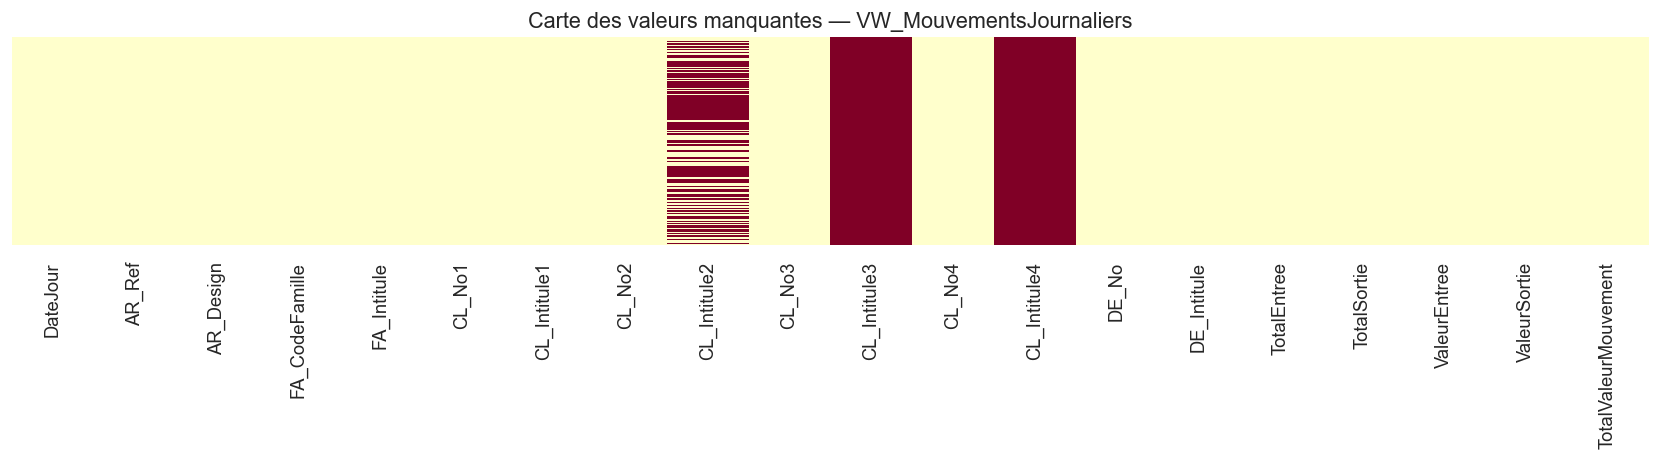

In [201]:
# Heatmap valeurs manquantes
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df_mvt.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='YlOrRd',
    ax=ax
)
ax.set_title("Carte des valeurs manquantes — VW_MouvementsJournaliers", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}missing_values_heatmap.png")
plt.show()

In [202]:
# Cellule 7 — Valeurs aberrantes (outliers)

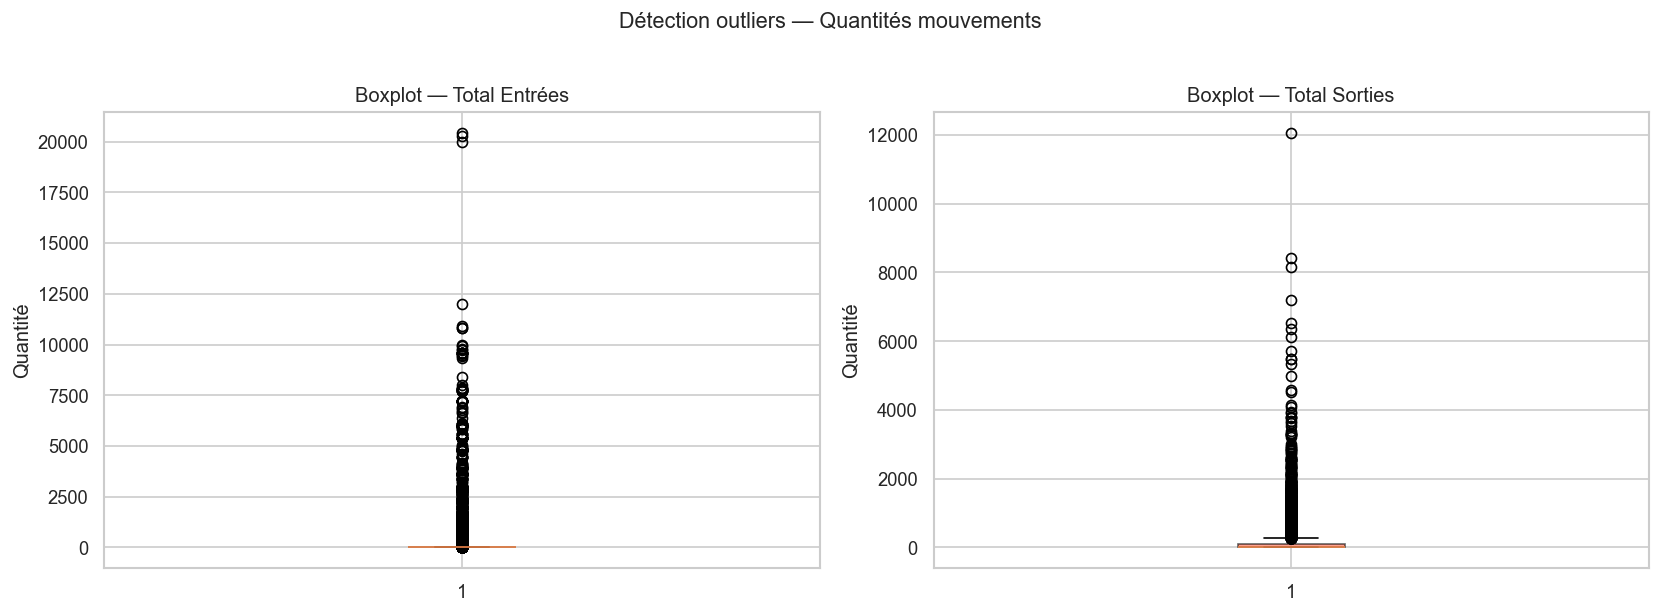

In [203]:
# ── Boxplot quantités entrées / sorties ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
    axes,
    ['TotalEntree', 'TotalSortie'],
    ['Total Entrées', 'Total Sorties'],
    ['steelblue', 'tomato']
):
    ax.boxplot(df_mvt[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f"Boxplot — {label}", fontsize=12)
    ax.set_ylabel("Quantité")

plt.suptitle("Détection outliers — Quantités mouvements", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}outliers_boxplot_quantites.png")
plt.show()

In [204]:
# ── Méthode IQR — identification des lignes aberrantes ───────
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in ['TotalEntree', 'TotalSortie', 'ValeurEntree', 'ValeurSortie']:
    out, lo, hi = detect_outliers_iqr(df_mvt, col)
    print(f"  {col:25s} → {len(out):4d} outliers  |  seuil bas: {lo:.1f}  |  seuil haut: {hi:.1f}")

  TotalEntree               → 2685 outliers  |  seuil bas: 0.0  |  seuil haut: 0.0
  TotalSortie               → 2264 outliers  |  seuil bas: -163.5  |  seuil haut: 280.5
  ValeurEntree              → 2508 outliers  |  seuil bas: 0.0  |  seuil haut: 0.0
  ValeurSortie              → 2349 outliers  |  seuil bas: -7932.7  |  seuil haut: 13897.4


In [205]:
# ── Top 10 lignes les plus aberrantes sur TotalSortie ────────
_, _, upper_s = detect_outliers_iqr(df_mvt, 'TotalSortie')

df_mvt[df_mvt['TotalSortie'] > upper_s]\
    .sort_values('TotalSortie', ascending=False)\
    [['DateJour','AR_Ref','AR_Design','DE_Intitule','TotalSortie','ValeurSortie']]\
    .head(10)\
    .reset_index(drop=True)

,DateJour,AR_Ref,AR_Design,DE_Intitule,TotalSortie,ValeurSortie
0,2023-03-30,MHCH003,"EDAM KROON 1,7 KG",OLAND,12070.86,1.030369e+06
1,2024-03-22,PPRF006,SLICE IWS OLAND 24P,OLAND,8412.00,1.169268e+05
2,2024-02-03,PHCH026,EDAM PORTION BABY KROON 100G,OLAND,8173.20,8.050602e+04
3,2024-01-29,N-5004,DOUBLE CONCENTRÉ DE TOMATE 37CL DÉLICIA-VERRE-,JOLY NGDM,7199.85,4.098515e+05
4,2024-11-19,PHCH026,EDAM PORTION BABY KROON 100G,OLAND,6533.00,6.435005e+04
5,2024-02-14,MHCH003,"EDAM KROON 1,7 KG",OLAND,6354.44,5.062301e+05
6,2024-10-01,PPRF006,SLICE IWS OLAND 24P,OLAND,6110.00,8.492900e+04
7,2024-05-10,MHCH003,"EDAM KROON 1,7 KG",OLAND,5728.61,4.563739e+05
8,2024-01-29,N-5003,CONCENTRÉ TOMATE 21CL DELICIA*12PCS,JOLY NGDM,5493.00,4.350456e+05
9,2024-05-22,VS6ML,Vatika Shampoo Nourish & Protect -6ml,DABUR CASA,5472.00,2.434493e+05


In [206]:
#Cellule 8 — Distribution des quantités

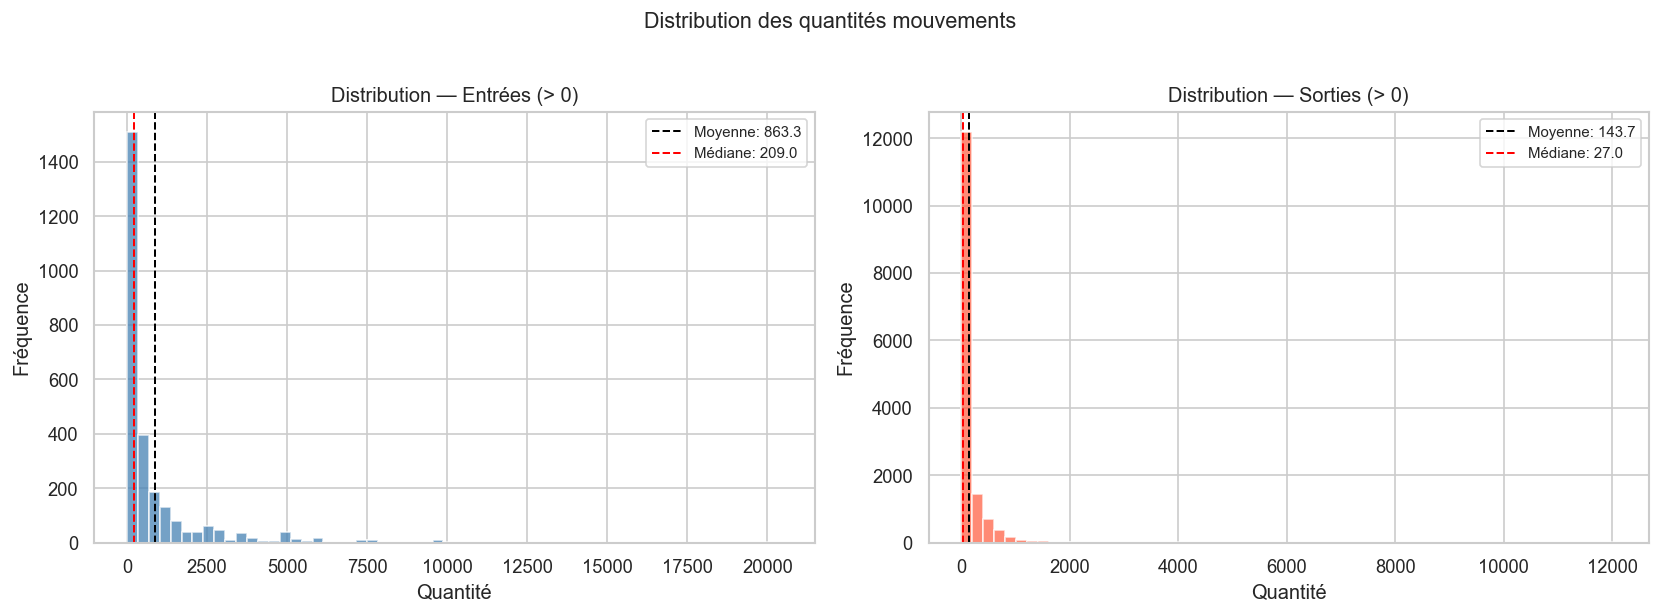

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['TotalEntree', 'TotalSortie'],
    ['steelblue', 'tomato'],
    ['Entrées', 'Sorties']
):
    data = df_mvt[df_mvt[col] > 0][col]
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Moyenne: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Médiane: {data.median():.1f}')
    ax.set_title(f"Distribution — {label} (> 0)", fontsize=12)
    ax.set_xlabel("Quantité")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=9)

plt.suptitle("Distribution des quantités mouvements", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}distribution_quantites.png")
plt.show()

In [208]:
# Cellule 9 — Évolution temporelle globale

In [209]:
# ── Agrégation journalière toutes bases ──────────────────────
df_daily = df_mvt.groupby('DateJour').agg(
    TotalEntree   = ('TotalEntree',  'sum'),
    TotalSortie   = ('TotalSortie',  'sum'),
    ValeurEntree  = ('ValeurEntree', 'sum'),
    ValeurSortie  = ('ValeurSortie', 'sum'),
    NbArticles    = ('AR_Ref',       'nunique')
).reset_index()

df_daily.tail()

,DateJour,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,NbArticles
581,2025-02-05,0.0,909.62,0.0,149912.98976,33
582,2025-05-23,0.0,13.00,0.0,0.00000,1
583,2025-08-04,0.0,1.00,0.0,105.00000,1
584,2025-08-27,2.0,0.00,0.0,0.00000,1
585,2025-10-01,0.0,44.00,0.0,7333.48000,1


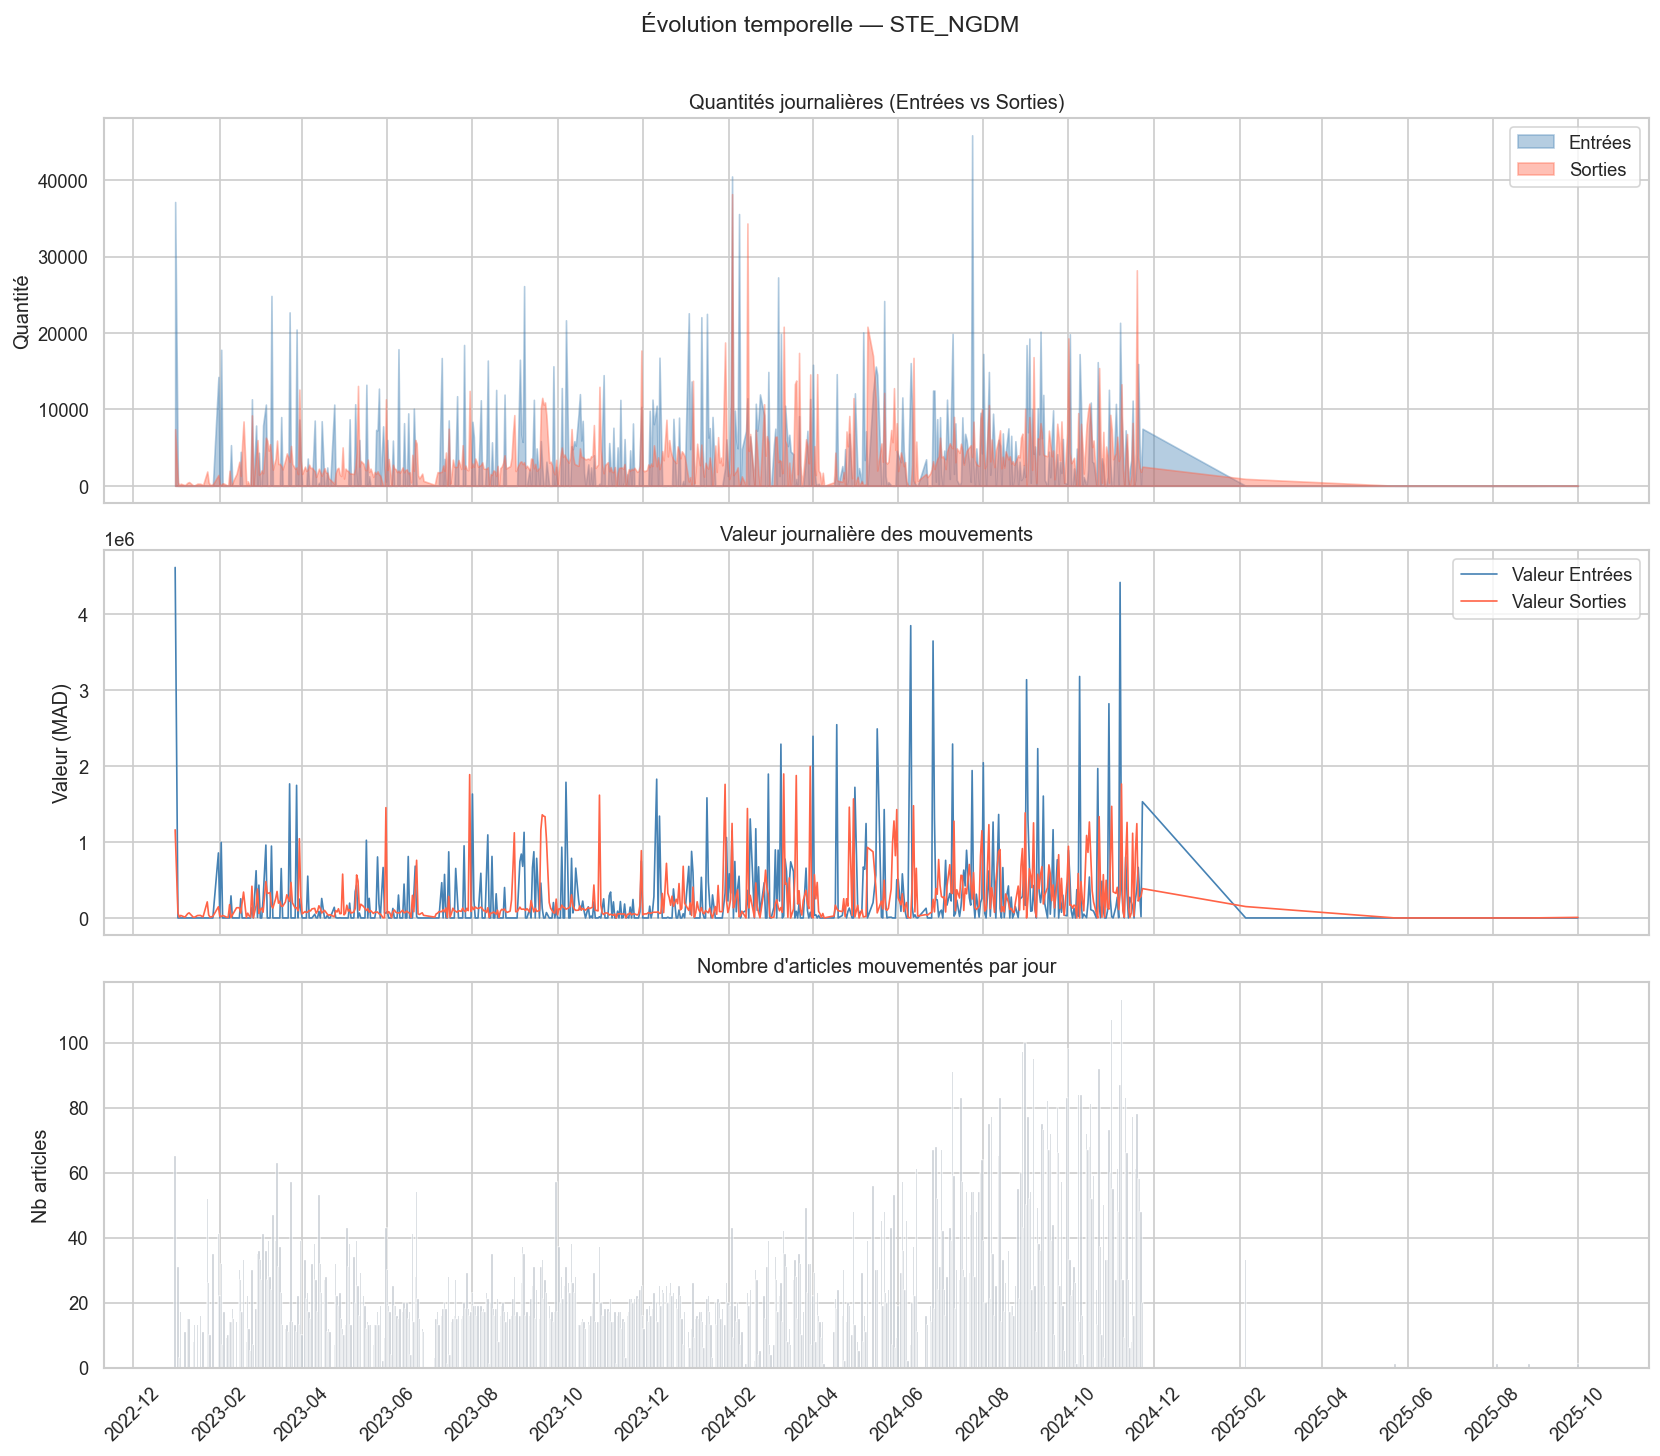

In [210]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Quantités ────────────────────────────────────────────────
axes[0].fill_between(df_daily['DateJour'], df_daily['TotalEntree'],
                     alpha=0.4, color='steelblue', label='Entrées')
axes[0].fill_between(df_daily['DateJour'], df_daily['TotalSortie'],
                     alpha=0.4, color='tomato', label='Sorties')
axes[0].set_title("Quantités journalières (Entrées vs Sorties)", fontsize=12)
axes[0].legend()
axes[0].set_ylabel("Quantité")

# ── Valeurs ───────────────────────────────────────────────────
axes[1].plot(df_daily['DateJour'], df_daily['ValeurEntree'],
             color='steelblue', linewidth=1, label='Valeur Entrées')
axes[1].plot(df_daily['DateJour'], df_daily['ValeurSortie'],
             color='tomato', linewidth=1, label='Valeur Sorties')
axes[1].set_title("Valeur journalière des mouvements", fontsize=12)
axes[1].legend()
axes[1].set_ylabel("Valeur (MAD)")

# ── Nb articles actifs ────────────────────────────────────────
axes[2].bar(df_daily['DateJour'], df_daily['NbArticles'],
            color='slategray', alpha=0.6, width=1)
axes[2].set_title("Nombre d'articles mouvementés par jour", fontsize=12)
axes[2].set_ylabel("Nb articles")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.suptitle(f"Évolution temporelle — {BASE_NAME}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}evolution_temporelle.png")
plt.show()

In [211]:
# Cellule 10 — Saisonnalité (mois / jour de semaine)

In [212]:
df_mvt['Mois']       = df_mvt['DateJour'].dt.month
df_mvt['Annee']      = df_mvt['DateJour'].dt.year
df_mvt['JourSemaine'] = df_mvt['DateJour'].dt.dayofweek  # 0=Lundi
df_mvt['NomJour']    = df_mvt['DateJour'].dt.day_name()

jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mois_labels  = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

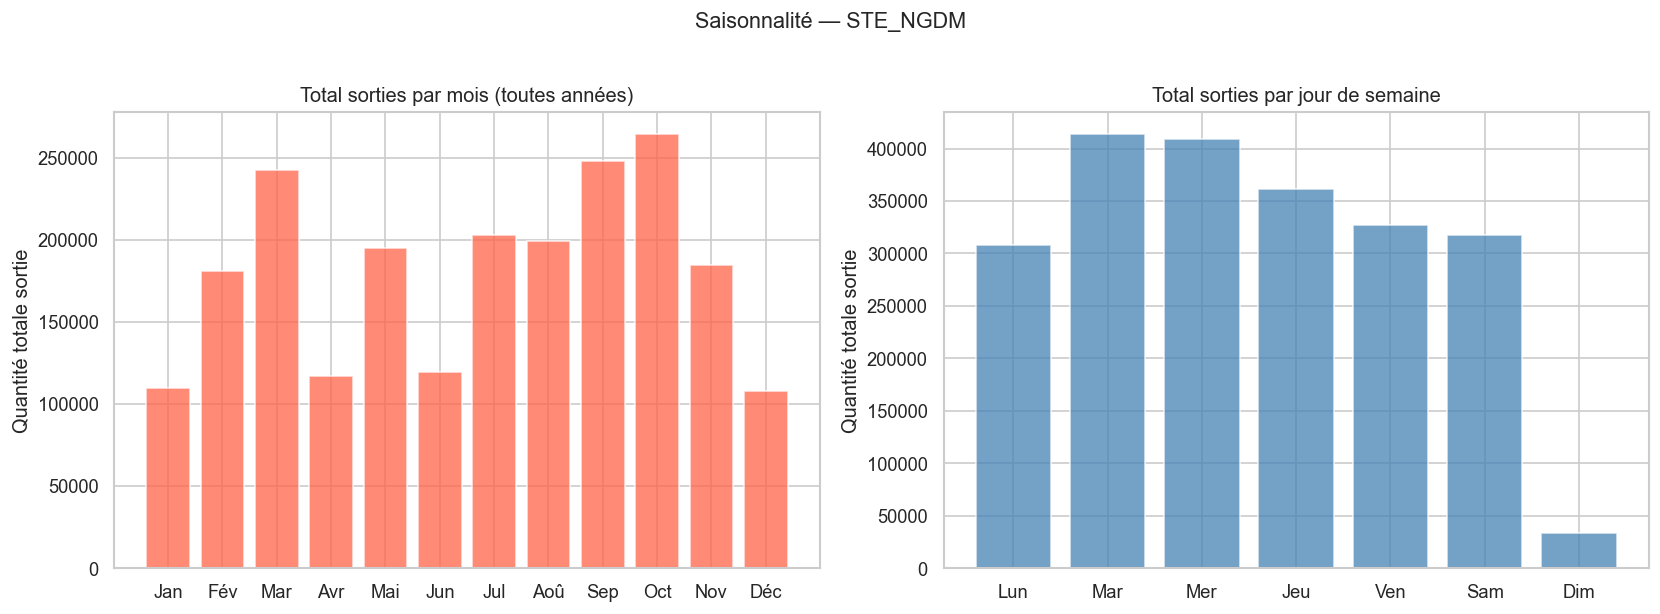

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Par mois ─────────────────────────────────────────────────
by_mois = df_mvt.groupby('Mois')['TotalSortie'].sum()
axes[0].bar(by_mois.index, by_mois.values, color='tomato', alpha=0.75)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mois_labels)
axes[0].set_title("Total sorties par mois (toutes années)", fontsize=12)
axes[0].set_ylabel("Quantité totale sortie")

# ── Par jour de semaine ───────────────────────────────────────
by_jour = df_mvt.groupby('NomJour')['TotalSortie'].sum().reindex(jours_ordre)
axes[1].bar(by_jour.index, by_jour.values, color='steelblue', alpha=0.75)
axes[1].set_xticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'])
axes[1].set_title("Total sorties par jour de semaine", fontsize=12)
axes[1].set_ylabel("Quantité totale sortie")

plt.suptitle(f"Saisonnalité — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}saisonnalite.png")
plt.show()

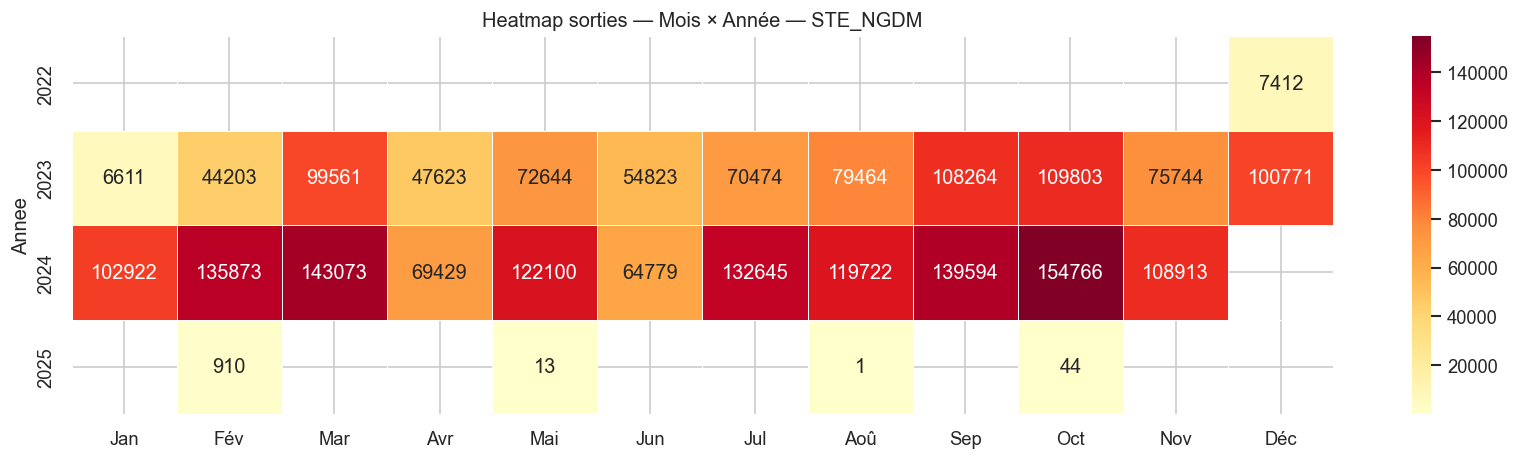

In [214]:
# ── Heatmap mois × année ─────────────────────────────────────
pivot_mois = df_mvt.pivot_table(
    values='TotalSortie',
    index='Annee',
    columns='Mois',
    aggfunc='sum'
)
pivot_mois.columns = mois_labels[:len(pivot_mois.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_mois, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax)
ax.set_title(f"Heatmap sorties — Mois × Année — {BASE_NAME}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}heatmap_mois_annee.png")
plt.show()

In [215]:
# Cellule 11 — Analyse par famille d'articles

In [216]:
by_famille = df_mvt.groupby(['FA_CodeFamille','FA_Intitule']).agg(
    TotalSortie  = ('TotalSortie',  'sum'),
    TotalEntree  = ('TotalEntree',  'sum'),
    ValeurSortie = ('ValeurSortie', 'sum'),
    NbJours      = ('DateJour',     'nunique'),
    NbArticles   = ('AR_Ref',       'nunique')
).reset_index().sort_values('TotalSortie', ascending=False)

by_famille.head(15)

,FA_CodeFamille,FA_Intitule,TotalSortie,TotalEntree,ValeurSortie,NbJours,NbArticles
26,OLAND,OLAND,788551.43,824345.57,1.547161e+07,488,31
18,KROON,KROON,355908.81,361382.11,2.906543e+07,484,8
34,TIFFANY,TIFFANY,244009.57,282934.58,4.065995e+07,195,22
23,MEJORCHEF,MEJOR_CHEF,241366.50,241366.50,8.190906e+06,364,5
35,TOMATE,TOMATE,93607.00,93786.00,2.077412e+05,362,1
1,BOULEDOR,BOULE_D_OR,79521.00,79521.00,1.102856e+06,444,5
2,CONFITURE,CONFITURE,76363.41,79780.41,7.878155e+06,168,15
21,MAQUEREAU,MAQUEREAU,56960.54,58622.69,1.145099e+07,180,16
7,DTOMATE,TOMATE DELICIA,44420.65,44420.65,3.525073e+06,116,7
32,THON,THON,28894.25,29694.25,5.799501e+06,154,21


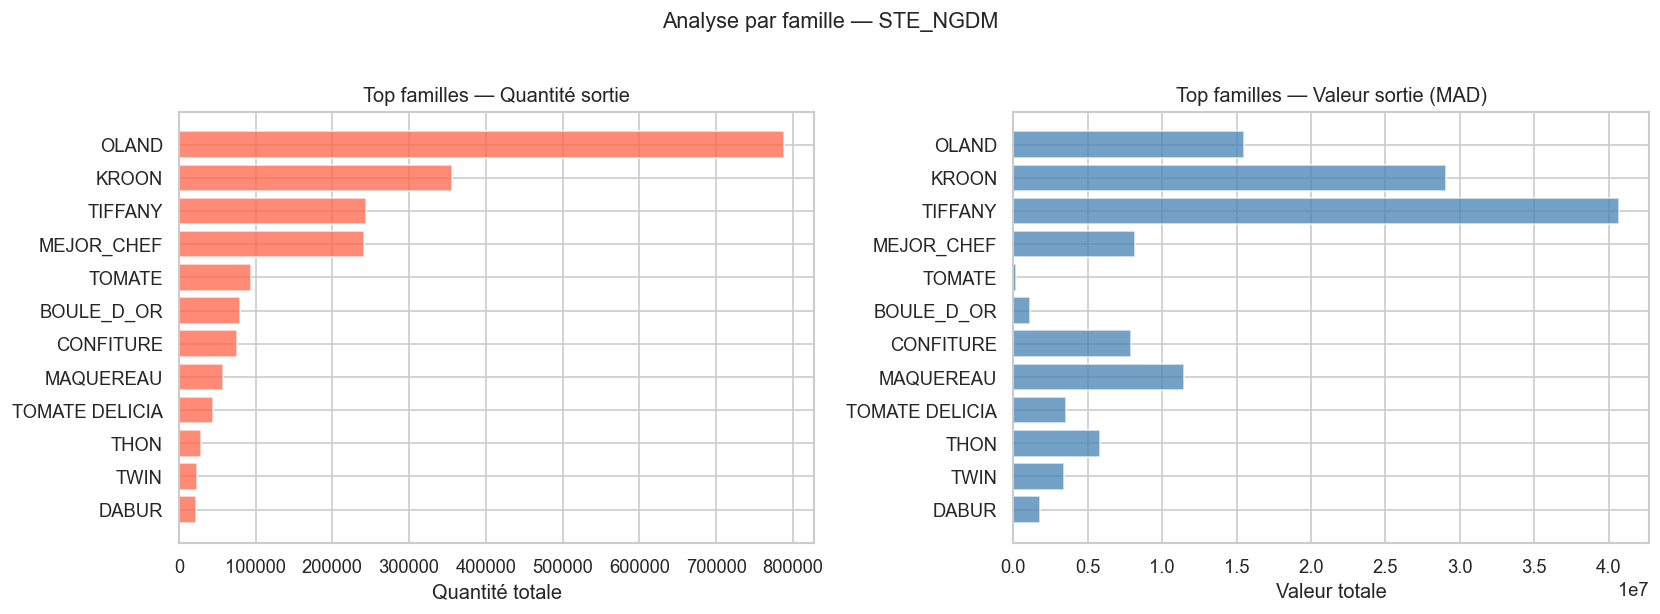

In [217]:
top_fam = by_famille.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Par quantité ──────────────────────────────────────────────
axes[0].barh(top_fam['FA_Intitule'], top_fam['TotalSortie'],
             color='tomato', alpha=0.75)
axes[0].invert_yaxis()
axes[0].set_title("Top familles — Quantité sortie", fontsize=12)
axes[0].set_xlabel("Quantité totale")

# ── Par valeur ────────────────────────────────────────────────
axes[1].barh(top_fam['FA_Intitule'], top_fam['ValeurSortie'],
             color='steelblue', alpha=0.75)
axes[1].invert_yaxis()
axes[1].set_title("Top familles — Valeur sortie (MAD)", fontsize=12)
axes[1].set_xlabel("Valeur totale")

plt.suptitle(f"Analyse par famille — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}top_familles.png")
plt.show()

In [218]:
# Cellule 12 — Top articles les plus mouvementés

In [219]:
by_article = df_mvt.groupby(['AR_Ref','AR_Design']).agg(
    TotalSortie   = ('TotalSortie',   'sum'),
    TotalEntree   = ('TotalEntree',   'sum'),
    ValeurSortie  = ('ValeurSortie',  'sum'),
    NbJoursSortie = ('DateJour',      'nunique'),
    MoyenneSortie = ('TotalSortie',   'mean')
).reset_index().sort_values('TotalSortie', ascending=False)

print(f"Nombre total d'articles distincts : {len(by_article):,}")
by_article.head(20)

Nombre total d'articles distincts : 278


,AR_Ref,AR_Design,TotalSortie,TotalEntree,ValeurSortie,NbJoursSortie,MoyenneSortie
94,MHCH003,"EDAM KROON 1,7 KG",328198.36,333283.90,2.656426e+07,481,682.325073
225,PHCH026,EDAM PORTION BABY KROON 100G,182837.33,198025.33,1.925701e+06,342,529.963275
228,PPRF006,SLICE IWS OLAND 24P,158614.00,158614.00,2.208176e+06,314,501.943038
229,PPRF007,TRIANGLE EL MEJOR CHEF 96P 16,128512.50,128512.50,6.609726e+06,348,367.178571
241,PPRF047,SLICE IWS VIVA CHEDDAR 24P (12U),105083.00,108000.00,1.426177e+06,175,600.474286
227,PPRF004,SLICE IWS EL MEJOR CHEF 24P,104566.00,104566.00,1.412817e+06,312,335.147436
107,MJTM002,COULIS DE TOMATES VERDE 110GR,93607.00,93786.00,2.077412e+05,362,256.457534
243,PPRF050,SLICE IWS VIVA SP BURGER 24P (12U),59382.54,61430.00,7.851574e+05,175,331.746034
235,PPRF028,TRIANGLE EL MEJOR CHEF 96P 24,55417.00,55398.00,2.824599e+06,209,263.890476
239,PPRF045,Triangles Original VIVA 96P 16,44157.32,47075.33,2.004061e+06,173,250.893864


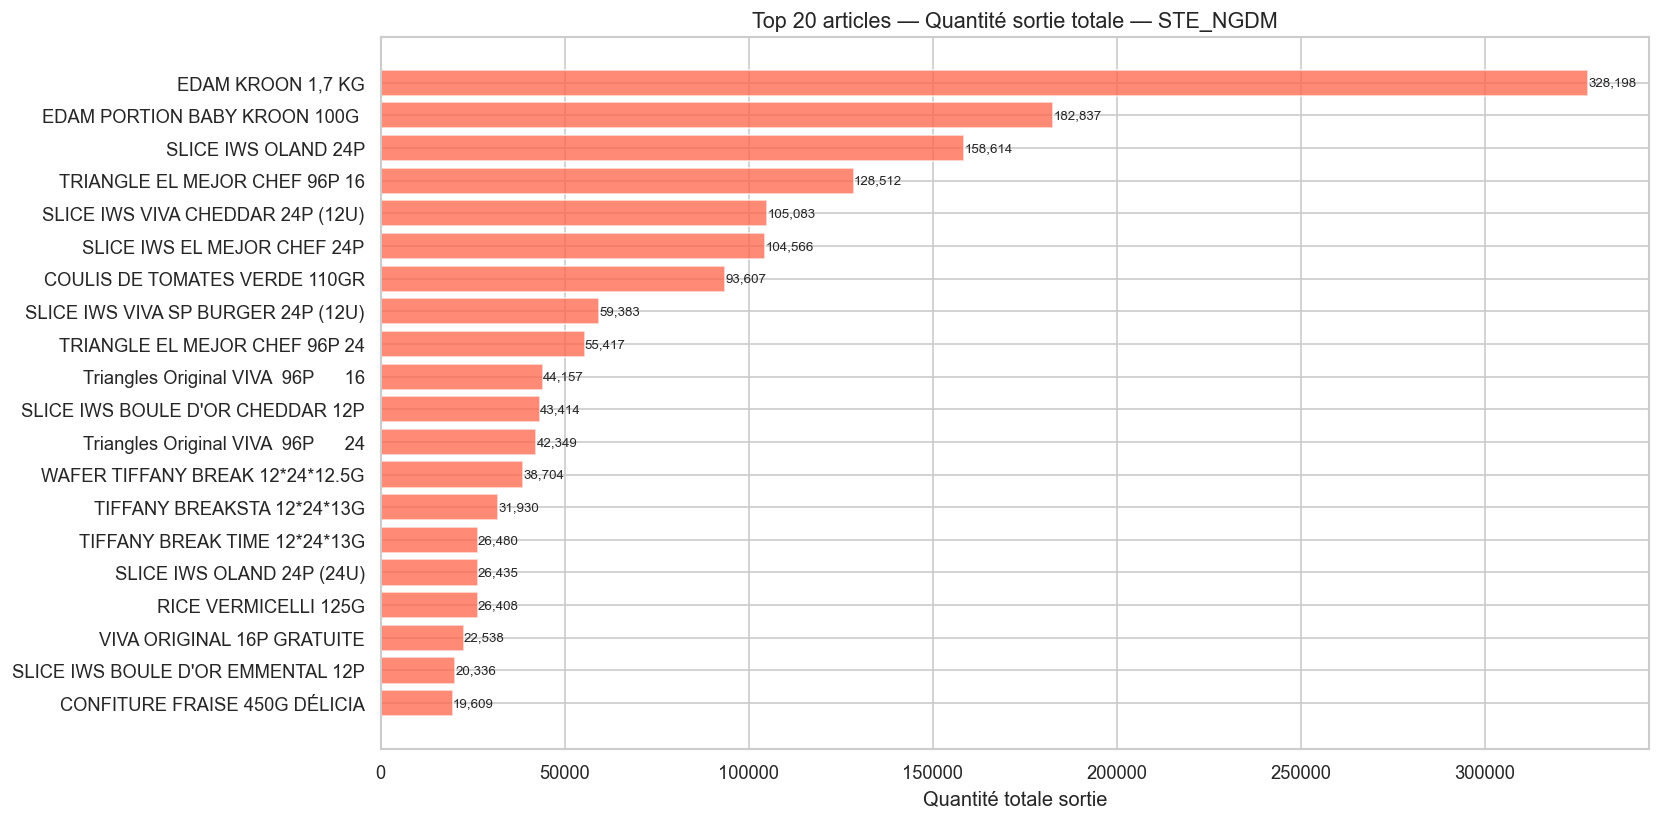

In [220]:
top20 = by_article.head(20)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top20['AR_Design'], top20['TotalSortie'],
               color='tomato', alpha=0.75)
ax.invert_yaxis()
ax.set_title(f"Top 20 articles — Quantité sortie totale — {BASE_NAME}", fontsize=13)
ax.set_xlabel("Quantité totale sortie")

for bar, val in zip(bars, top20['TotalSortie']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}top20_articles.png")
plt.show()

In [221]:
# Cellule 13 — Analyse par dépôt

In [222]:
by_depot = df_mvt.groupby(['DE_No','DE_Intitule']).agg(
    TotalSortie  = ('TotalSortie',  'sum'),
    TotalEntree  = ('TotalEntree',  'sum'),
    ValeurSortie = ('ValeurSortie', 'sum'),
    NbArticles   = ('AR_Ref',       'nunique'),
    NbJours      = ('DateJour',     'nunique')
).reset_index().sort_values('TotalSortie', ascending=False)

by_depot

,DE_No,DE_Intitule,TotalSortie,TotalEntree,ValeurSortie,NbArticles,NbJours
2,6,OLAND,1564668.79,1606147.23,5.394876e+07,54,516
0,2,JOLY NGDM,223604.10,229682.25,3.120502e+07,82,213
3,8,TIFFANYCASA,159868.30,179043.73,2.636546e+07,25,142
4,9,TIFFANYRABAT,86547.44,107396.85,1.458403e+07,25,173
7,12,MOLFIX CASA,72144.48,103221.32,9.906820e+06,26,95
6,11,DABUR RABAT,41072.67,62982.13,9.822442e+06,85,127
10,15,DABUR CASA,12560.82,15382.36,2.045370e+06,68,56
1,3,OLAND NC,5560.95,5560.95,1.983772e+05,27,4
9,14,LANDOR,3545.29,3545.70,5.815748e+05,8,12
8,13,DABUR TANGER,1934.26,4180.70,5.292759e+05,82,43


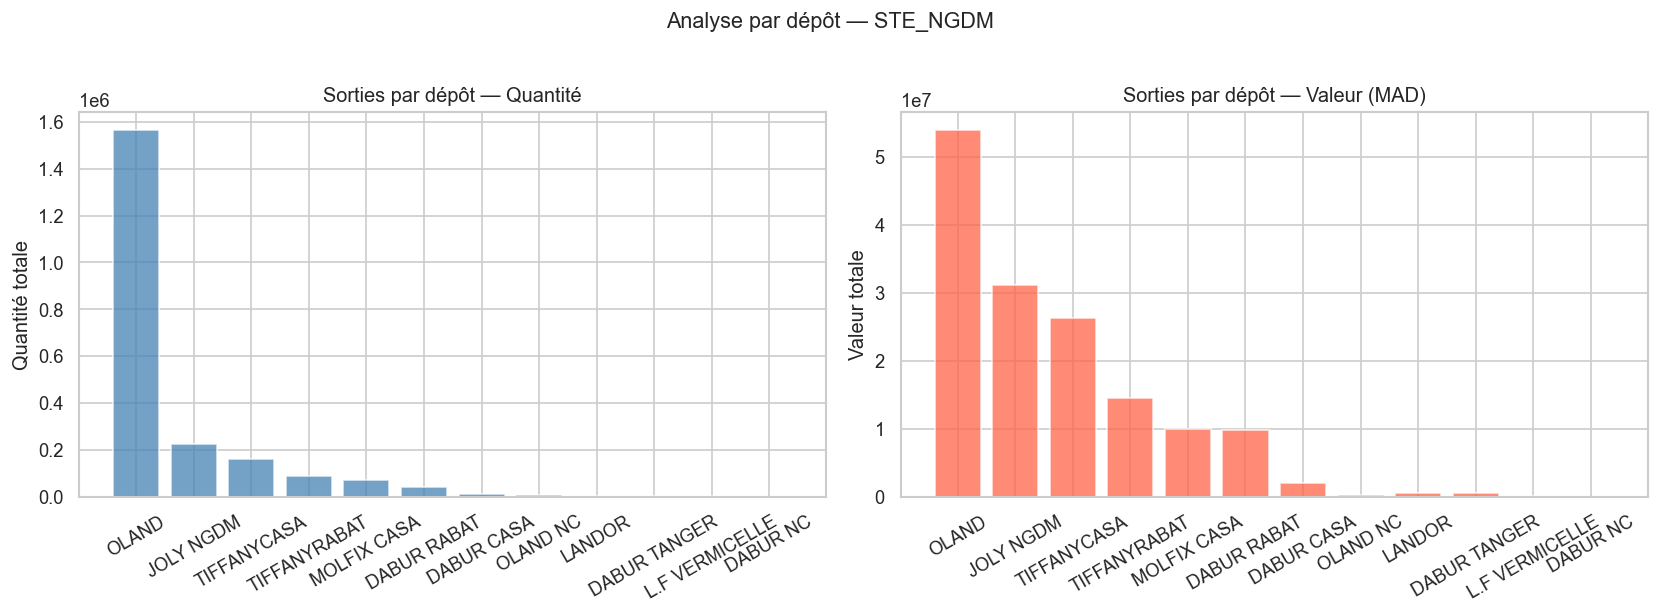

In [223]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(by_depot['DE_Intitule'], by_depot['TotalSortie'],
            color='steelblue', alpha=0.75)
axes[0].set_title("Sorties par dépôt — Quantité", fontsize=12)
axes[0].set_ylabel("Quantité totale")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(by_depot['DE_Intitule'], by_depot['ValeurSortie'],
            color='tomato', alpha=0.75)
axes[1].set_title("Sorties par dépôt — Valeur (MAD)", fontsize=12)
axes[1].set_ylabel("Valeur totale")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f"Analyse par dépôt — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analyse_depots.png")
plt.show()

In [224]:
# Cellule 14 — Corrélations

In [225]:
cols_corr = ['TotalEntree','TotalSortie','ValeurEntree','ValeurSortie','TotalValeurMouvement']
corr_matrix = df_mvt[cols_corr].corr().round(2)
corr_matrix

,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
TotalEntree,1.00,0.13,0.67,0.05,0.58
TotalSortie,0.13,1.00,0.06,0.69,-0.29
ValeurEntree,0.67,0.06,1.00,0.07,0.86
ValeurSortie,0.05,0.69,0.07,1.00,-0.45
TotalValeurMouvement,0.58,-0.29,0.86,-0.45,1.00


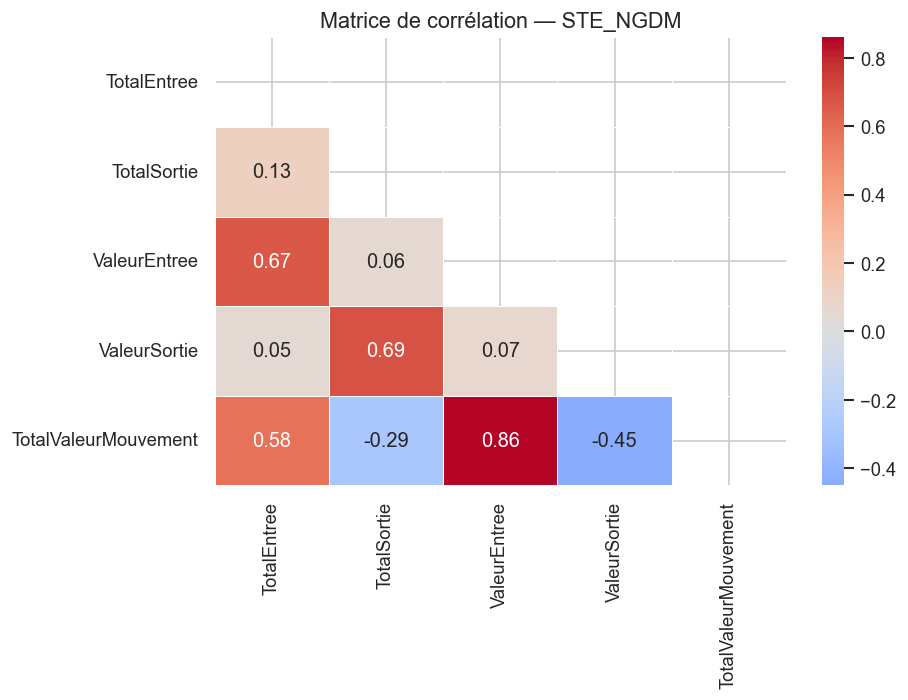

In [226]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Matrice de corrélation — {BASE_NAME}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}correlation_matrix.png")
plt.show()

,Lag (jours),Corrélation Entrée↔Sortie
0,0,0.178
1,1,0.059
2,2,0.056
3,3,0.015
4,4,0.033
5,5,0.175
6,6,0.048
7,7,0.088


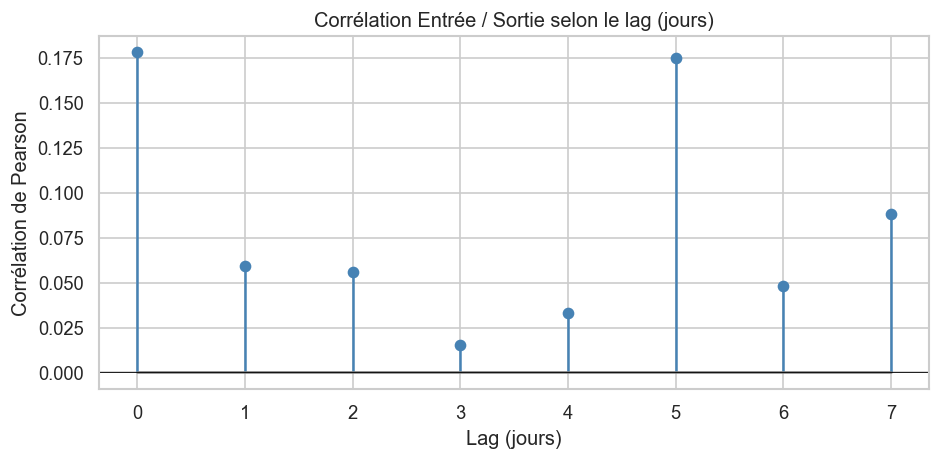

In [227]:
# ── Corrélation Entrée / Sortie par article (lag 0→7 jours) ──
lags = range(0, 8)
correlations = []

for lag in lags:
    df_lag = df_daily.copy()
    df_lag['Sortie_lag'] = df_lag['TotalSortie'].shift(lag)
    r = df_lag['TotalEntree'].corr(df_lag['Sortie_lag'])
    correlations.append({'Lag (jours)': lag, 'Corrélation Entrée↔Sortie': round(r, 3)})

df_lag_corr = pd.DataFrame(correlations)
display(df_lag_corr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_lag_corr['Lag (jours)'], df_lag_corr['Corrélation Entrée↔Sortie'],
        linefmt='steelblue', markerfmt='o', basefmt='gray')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title("Corrélation Entrée / Sortie selon le lag (jours)", fontsize=12)
ax.set_xlabel("Lag (jours)")
ax.set_ylabel("Corrélation de Pearson")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}correlation_lag_entree_sortie.png")
plt.show()

In [228]:
# Cellule 15 — Analyse du stock (depuis StockJournalierCache)

In [229]:
# ── Stock final moyen par article (top 20) ───────────────────
by_stock = df_stock.groupby(['AR_Ref','AR_Design']).agg(
    StockFinalMoyen  = ('StockFinal',   'mean'),
    StockFinalMax    = ('StockFinal',   'max'),
    StockFinalMin    = ('StockFinal',   'min'),
    ValeurFinaleMoy  = ('ValeurFinale', 'mean'),
    NbJours0         = ('StockFinal',   lambda x: (x == 0).sum())
).reset_index()

by_stock['% jours à zéro'] = (by_stock['NbJours0'] / df_stock['DateJour'].nunique() * 100).round(1)
by_stock = by_stock.sort_values('StockFinalMoyen', ascending=False)

print("Top 20 articles — Stock final moyen :")
by_stock.head(20)

Top 20 articles — Stock final moyen :


,AR_Ref,AR_Design,StockFinalMoyen,StockFinalMax,StockFinalMin,ValeurFinaleMoy,NbJours0,% jours à zéro
201,N5006,Molfix 3D UV E.LARGE 22*4 Twin,7011.240000,10313.00,1298.00,1.010641e+06,0,0.0
277,VS6ML,Vatika Shampoo Nourish & Protect -6ml,6962.544737,16954.70,-60.00,2.324771e+05,0,0.0
199,N5004,Molfix 3D UV Maxi 36*4 Twin,6954.219773,10107.00,1726.00,1.002422e+06,0,0.0
200,N5005,Molfix 3D UV Junior 28*4 Twin,6715.546170,10125.00,2572.00,9.680246e+05,0,0.0
94,MHCH003,"EDAM KROON 1,7 KG",6588.997360,32847.40,-1563.65,5.361513e+05,0,0.0
225,PHCH026,EDAM PORTION BABY KROON 100G,6471.888522,22961.00,-51.71,7.562265e+04,1,0.2
228,PPRF006,SLICE IWS OLAND 24P,5050.123386,22126.00,-6203.00,7.019078e+04,2,0.3
107,MJTM002,COULIS DE TOMATES VERDE 110GR,4798.383507,12105.00,-2.00,1.103722e+04,1,0.2
227,PPRF004,SLICE IWS EL MEJOR CHEF 24P,4448.390929,12048.00,-701.00,6.010955e+04,1,0.2
241,PPRF047,SLICE IWS VIVA CHEDDAR 24P (12U),4260.274057,16854.00,5.00,5.813054e+04,0,0.0


In [230]:
# ── Articles à risque de rupture (>30% jours à stock=0) ──────
rupture_risk = by_stock[by_stock['% jours à zéro'] > 30]\
    .sort_values('% jours à zéro', ascending=False)

print(f"⚠️  Articles à risque de rupture (> 30% des jours à stock nul) : {len(rupture_risk)}")
rupture_risk[['AR_Ref','AR_Design','StockFinalMoyen','% jours à zéro']].head(20)

⚠️  Articles à risque de rupture (> 30% des jours à stock nul) : 0


,AR_Ref,AR_Design,StockFinalMoyen,% jours à zéro


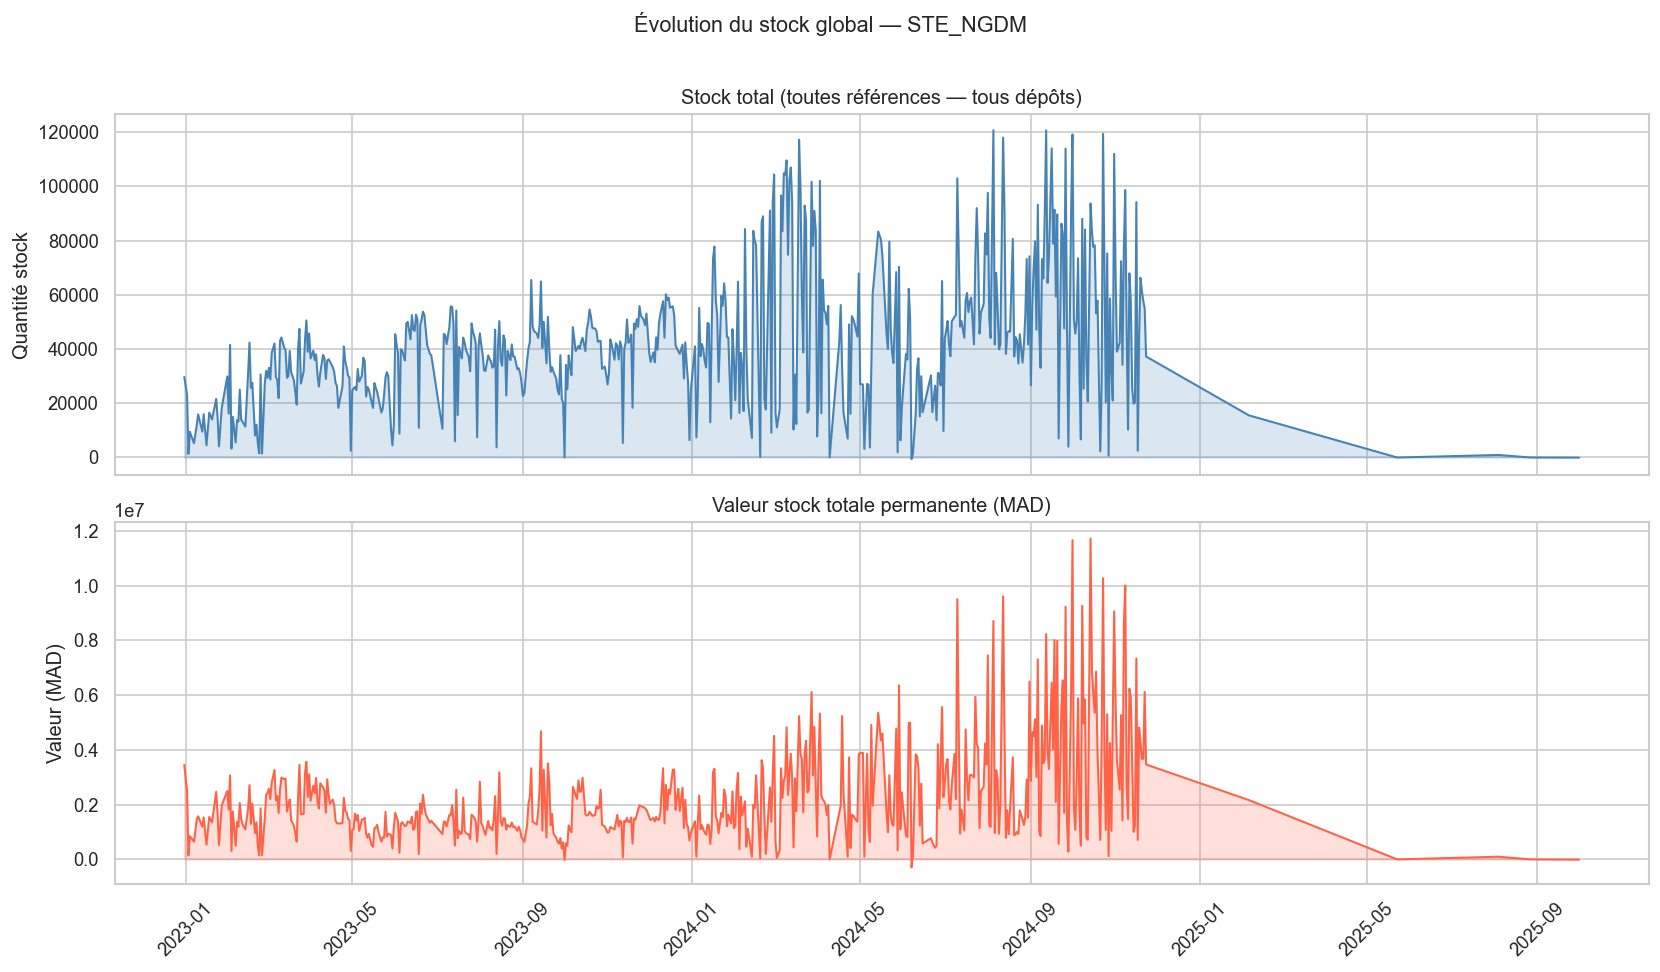

In [231]:
# ── Évolution stock global (somme StockFinal tous articles) ──
df_stock_global = df_stock.groupby('DateJour').agg(
    StockTotal   = ('StockFinal',   'sum'),
    ValeurTotale = ('ValeurFinale', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_stock_global['DateJour'], df_stock_global['StockTotal'],
             color='steelblue', linewidth=1.2)
axes[0].fill_between(df_stock_global['DateJour'], df_stock_global['StockTotal'],
                     alpha=0.2, color='steelblue')
axes[0].set_title("Stock total (toutes références — tous dépôts)", fontsize=12)
axes[0].set_ylabel("Quantité stock")

axes[1].plot(df_stock_global['DateJour'], df_stock_global['ValeurTotale'],
             color='tomato', linewidth=1.2)
axes[1].fill_between(df_stock_global['DateJour'], df_stock_global['ValeurTotale'],
                     alpha=0.2, color='tomato')
axes[1].set_title("Valeur stock totale permanente (MAD)", fontsize=12)
axes[1].set_ylabel("Valeur (MAD)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.suptitle(f"Évolution du stock global — {BASE_NAME}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}evolution_stock_global.png")
plt.show()

In [232]:
# Cellule 16 — Analyse des doublons 

In [233]:
doublons = df_mvt.duplicated(subset=['DateJour','AR_Ref','DE_No']).sum()
print(f"Doublons (DateJour + AR_Ref + DE_No) : {doublons}")

Doublons (DateJour + AR_Ref + DE_No) : 0


In [234]:
# Cellule 17 — Continuité temporelle

In [235]:
all_dates = pd.date_range(df_mvt['DateJour'].min(), df_mvt['DateJour'].max())
dates_presentes = df_mvt['DateJour'].unique()
trous = [d for d in all_dates if d not in dates_presentes]
print(f"Jours sans aucun mouvement : {len(trous)}")
pd.DataFrame({'Date manquante': trous})

Jours sans aucun mouvement : 420


,Date manquante
0,2023-01-01
1,2023-01-05
2,2023-01-06
3,2023-01-08
4,2023-01-11
...,...
415,2025-09-26
416,2025-09-27
417,2025-09-28
418,2025-09-29


In [236]:
# Cellule 19 — Distribution des articles par fréquence de sortie

In [237]:
freq = df_mvt[df_mvt['TotalSortie'] > 0]\
    .groupby('AR_Ref')['DateJour'].nunique()\
    .reset_index()\
    .rename(columns={'DateJour': 'NbJoursSortie'})

bins = [0, 10, 30, 90, 180, 365, 9999]
labels = ['< 10j', '10-30j', '30-90j', '90-180j', '180-365j', '> 365j']
freq['Segment'] = pd.cut(freq['NbJoursSortie'], bins=bins, labels=labels)

display(freq['Segment'].value_counts().reset_index()\
    .rename(columns={'index':'Segment fréquence','Segment':'Nb articles'}))

,Nb articles,count
0,30-90j,93
1,< 10j,79
2,10-30j,67
3,90-180j,21
4,180-365j,14
5,> 365j,2


In [238]:
# Cellule 20 —Concentration type Pareto 80/20

In [239]:
by_art_sorted = by_article.sort_values('TotalSortie', ascending=False).copy()
by_art_sorted['CumulPct'] = by_art_sorted['TotalSortie'].cumsum() / by_art_sorted['TotalSortie'].sum() * 100

seuil_80 = by_art_sorted[by_art_sorted['CumulPct'] <= 80]
print(f"Pareto : {len(seuil_80)} articles ({len(seuil_80)/len(by_art_sorted)*100:.1f}%) représentent 80% des sorties")

Pareto : 31 articles (11.2%) représentent 80% des sorties


In [240]:
# Cellule 21 — Résumé final et export

In [241]:
print("=" * 60)
print(f"  RÉSUMÉ EXPLORATION — {BASE_NAME}")
print("=" * 60)

print(f"""
📦 Données mouvements
   Lignes totales         : {len(df_mvt):,}
   Période                : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}
   Nb articles distincts  : {df_mvt['AR_Ref'].nunique():,}
   Nb dépôts              : {df_mvt['DE_No'].nunique()}
   Nb familles            : {df_mvt['FA_CodeFamille'].nunique()}

📊 Valeurs manquantes
   Colonnes impactées     : {(df_mvt.isnull().sum() > 0).sum()}

⚠️  Outliers (méthode IQR)
   TotalSortie            : {len(detect_outliers_iqr(df_mvt, 'TotalSortie')[0]):,} lignes
   ValeurSortie           : {len(detect_outliers_iqr(df_mvt, 'ValeurSortie')[0]):,} lignes

🔴 Articles à risque rupture (>30% jours stock=0)
   Nb articles            : {len(rupture_risk)}

📁 Graphes exportés dans :
   {OUTPUT_DIR}
""")

  RÉSUMÉ EXPLORATION — STE_NGDM

📦 Données mouvements
   Lignes totales         : 16,972
   Période                : 2022-12-31 → 2025-10-01
   Nb articles distincts  : 278
   Nb dépôts              : 12
   Nb familles            : 38

📊 Valeurs manquantes
   Colonnes impactées     : 3

⚠️  Outliers (méthode IQR)
   TotalSortie            : 2,264 lignes
   ValeurSortie           : 2,349 lignes

🔴 Articles à risque rupture (>30% jours stock=0)
   Nb articles            : 0

📁 Graphes exportés dans :
   ..\..\output\STE_NGDM\exploration



In [242]:
# ── Export résumé CSV ─────────────────────────────────────────
by_article.to_csv(f"{OUTPUT_DIR}resume_articles.csv", index=False)
by_famille.to_csv(f"{OUTPUT_DIR}resume_familles.csv", index=False)
rupture_risk.to_csv(f"{OUTPUT_DIR}articles_risque_rupture.csv", index=False)

print("✅ Fichiers CSV exportés")

conn.close()
print("✅ Connexion SQL fermée")

✅ Fichiers CSV exportés
✅ Connexion SQL fermée
